In [1]:
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd

from tsp_backend import polar_to_cartesian, plot_tsp_route, simmulated_annealing_tsp, constant_traffic_factor_func, nearest_neighbor_tsp, calculate_route_cost, make_distance_matrix, check_if_in_polygon



In [2]:
def traffic_factor_no_traffic(cost : float) -> float:
    return constant_traffic_factor_func(1.0, 0.0, cost)

def traffic_factor_with_traffic(cost : float) -> float:
    return constant_traffic_factor_func(10.0, 4.0, cost)

# Circle

In [3]:
N = 8
R = 1
phi = np.array([2 * np.pi * i / N + np.pi / 2 for i in range(0,N)])

nodes_circle_N_8 = polar_to_cartesian(R, phi)

In [4]:
%%timeit

optimal_circle_N_8, optimal_cost_circle_N_8 = simmulated_annealing_tsp(
    nodes_circle_N_8, 
    traffic_factor=traffic_factor_no_traffic, 
    start_point_index=0, 
    rejection_threshold=[20,20,20,20], 
    plot_cost=False, 
    plot_cost_out_path='plots/convergence_circle_N_8.pdf')

Temperature: 0.1, Current Cost: 12.335983551923748
Current route: [0 7 2 4 1 5 6 3]
num consec rejections: 0, num iter: 0
Temperature: 0.05, Current Cost: 6.122934917841436
Current route: [0 7 6 5 4 3 2 1]
num consec rejections: 23, num iter: 264
Temperature: 0.01, Current Cost: 6.122934917841436
Current route: [0 1 2 3 4 5 6 7]
num consec rejections: 21, num iter: 64
Temperature: 0.001, Current Cost: 6.122934917841436
Current route: [0 1 2 3 4 5 6 7]
num consec rejections: 22, num iter: 64
Temperature: 0.1, Current Cost: 12.855766616872039
Current route: [0 4 2 6 3 1 5 7]
num consec rejections: 0, num iter: 0
Temperature: 0.05, Current Cost: 7.420628313127267
Current route: [0 1 7 6 5 4 3 2]
num consec rejections: 22, num iter: 58
Temperature: 0.01, Current Cost: 7.420628313127267
Current route: [0 1 7 6 5 4 3 2]
num consec rejections: 24, num iter: 24
Temperature: 0.001, Current Cost: 6.122934917841436
Current route: [0 1 2 3 4 5 6 7]
num consec rejections: 21, num iter: 86
Temperatu

KeyboardInterrupt: 

In [ ]:
%%timeit -r 20

nearest_neighbor_circle_N_8 = nearest_neighbor_tsp(nodes_circle_N_8, start_point_index=0)

# Large Circle


In [ ]:
N = 100
R = 1
phi = np.array([2 * np.pi * i / N + np.pi / 2 for i in range(0,N)])

nodes_circle_N_100 = polar_to_cartesian(R, phi)

Temperature: 0.1, Current Cost: 122.75404546247573
Current route: [ 0 93 99  4 66 34 54 43  9 41 28 39 33 72 19 76 13 23 47 14 45 89 63 16
 32 94 25 12 77 92 75 73 24 81 71 58 85 17 46 86 90 98 97 37 22 87 27  7
 15 29 11 62 56 51 42 40 67 65 50 52 68 64 80 82 49  6 57 21 91 88 69 60
 38 83 59  1 84 30  5 26 10 95 35  8  2 36 18 70 31 20 79 53 96 44  3 48
 55 74 78 61]
num consec rejections: 0, num iter: 0
Temperature: 0.05, Current Cost: 24.737597180626707
Current route: [ 0 97 95 94 91 82 84 79 76 74 72 54 55 52 50 51 57 61 62 59 60 65 64 53
 58 56 77 81 89 87 86 85 88 90 96 93 92 83 80 78 73 70 66 71 68 75 69 67
 63 47 45 44 39 42 41 40 37 35 36 38 49 48 46 43 34 31 30 29 33 32 23 12
 11  8 10 13 18 17 20 21 19 14  5  2  4  7  9 15 16 26 24 27 28 22 25  6
  3  1 98 99]
num consec rejections: 39, num iter: 2115
Temperature: 0.01, Current Cost: 18.129500322557938
Current route: [ 0 99 98 97 95 94 90 93 96 92 91 88 87 86 85 81 82 89 83 84 77 74 73 75
 76 79 80 78 68 70 72 71 69 67 56 5

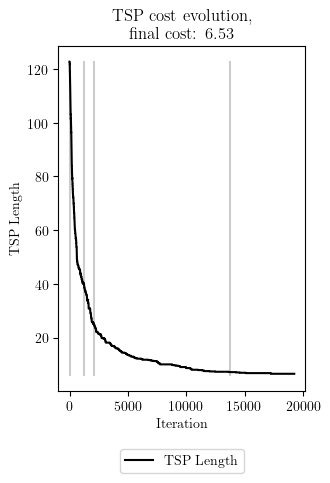

CPU times: total: 1.78 s
Wall time: 2.56 s


In [ ]:
%%timeit -r 20

optimal_circle_N_100, optimal_cost_circle_N_100 = simmulated_annealing_tsp(
    nodes_circle_N_100, 
    traffic_factor=traffic_factor_no_traffic, 
    start_point_index=0, 
    plot_cost=False, 
    plot_cost_out_path='plots/convergence_circle_N_100.pdf')

In [ ]:
%%timeit -r 20

nearest_neighbor_circle_N_100 = nearest_neighbor_tsp(nodes_circle_N_100, start_point_index=0)

CPU times: total: 0 ns
Wall time: 16.1 ms


# Two seperated squares of equal lattice nodes

In [ ]:
N = 10

x_coordinates_1 = np.linspace(-1.1, -0.1, N)
y_coordinates_1 = np.linspace(0.1 , 1.1, N)

X, Y = np.meshgrid(x_coordinates_1, y_coordinates_1)
coordinates_1 = np.column_stack([X.flatten(), Y.flatten()])

x_coordinates_2 = np.linspace(0.1, 1.1, N)
y_coordinates_2 = np.linspace(-1.1 , -0.1, N)

X, Y = np.meshgrid(x_coordinates_2, y_coordinates_2)
coordinates_2 = np.column_stack([X.flatten(), Y.flatten()])

nodes_two_squares = np.append(coordinates_1, coordinates_2, axis=0)

Temperature: 0.1, Current Cost: 228.26343777411478
Current route: [  0 114  51 186  72 142  96  28  16  58 170  69   2 152 115 188 125 101
 139 178  33 183 121  95 162 167  40  23  92 107 138 157 181 194 117  31
  56  17  94 134 127 172  80 176 132 148 146  20 113  30 189 160 179  57
  75  91  45 129 141 110 185  93  46  82 163  41 108  47  54  14  48  65
 106  87 120 151  86  83   8 149  21   6  49 136  76 159 137  79 156  36
 130   9  18 133 174 169  74  53  29 102 104  90 103 190  34  61 187 116
 153 197  15 184 195 123  24  22 180  44  13  64 111  97  63  68  88 193
  43  11 175 145 171 144 135 177 124 118 154  38 126 100  70 150   4  66
 199 158  62   5  77 166 196  71 165  85  35 191 128  32  25  60  89 192
 155 161   1 182 168  42 147 198  78  99  55 143   3  12 173  39 109  19
  50  73 164 105 131 112  81  98  10  27   7  59  52  26 140 119  67 122
  37  84]
num consec rejections: 0, num iter: 0
Temperature: 0.05, Current Cost: 61.62794227027038
Current route: [  0  21  20   2 

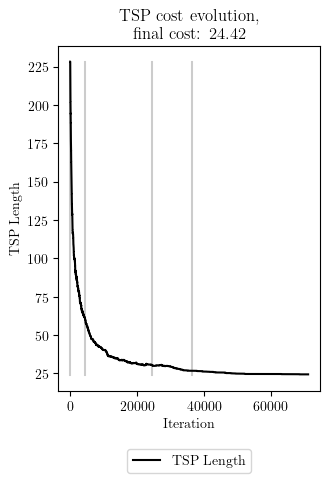

CPU times: total: 10.6 s
Wall time: 11.3 s


In [ ]:
%%timeit -r 20

optimal_two_square_N_10, optimal_two_square_cost_N_10 = simmulated_annealing_tsp(nodes_two_squares, 
                                                                                  traffic_factor=traffic_factor_no_traffic, 
                                                                                  start_point_index=0, 
                                                                                  max_iter_per_temperature=1e5,
                                                                                  plot_cost=False, 
                                                                                  plot_cost_out_path='plots/convergence_two_squares_N_10.pdf')

In [ ]:
%%timeit -r 20

nearest_neighbor_two_square_N_10 = nearest_neighbor_tsp(nodes_two_squares, start_point_index=0)

CPU times: total: 62.5 ms
Wall time: 53.7 ms


# Random points in a unit square

In [ ]:
N = 100
x = np.random.rand(N)
y = np.random.rand(N)
nodes_random_N_100 = np.column_stack([x, y])

Temperature: 0.1, Current Cost: 53.67855675115872
Current route: [ 0 91 85 36 45 54 19 96 16 62 92 75 82 88  9 64 97 93  6 14 18 47 49 95
 79 84  5 37 53 78 41 33 61  2 13 55  7 10 56 48 69 11 31 99 98 72 52 89
 29 25 77 51 81 38 42 90 30 50 87 94 57 46 44 76  3 70 68 26 66 43 15 17
 23 59 28 40  4  1 27 35 20 63 65 58 21 73 60 12 34 83 86 80 39 67 22 32
  8 71 24 74]
num consec rejections: 0, num iter: 0
Temperature: 0.05, Current Cost: 20.022153875598406
Current route: [ 0 75 61 92 19 93 96 62 80 35 60 88 44 70 31  2 11 29 32 52 84 48 50 15
 27 79  5 69 72 41 42 90 66 57 16 58 47 34 53 74 26  9 82 18 25  8  4 54
 87 39 63  6  7 83 94 51 68 78 77  3 38 71 95 65 37 64 85 56 36 17 13  1
 22 99 46 89 30 81 73 49 76 21 40 28 33 12 45 67 86 14 20 23 59 98 91 24
 55 97 43 10]
num consec rejections: 26, num iter: 3682
Temperature: 0.01, Current Cost: 13.056503780688365
Current route: [ 0 43 31  2 89 60 99 69 53 72 15 90 46 47 34 97 39 63 87 51  7 68 57  6
  5 45 86 14  8 27 67 20 30 12 21 76

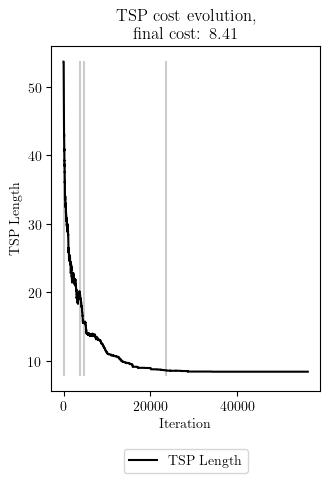

CPU times: total: 5.03 s
Wall time: 5.59 s


In [ ]:
%%timeit -r 20

optimal_random_square_N_100, optimal_random_square_cost_N_100 = simmulated_annealing_tsp(nodes_random_N_100, 
                                                                                  traffic_factor=traffic_factor_no_traffic, 
                                                                                  start_point_index=0, 
                                                                                  max_iter_per_temperature=1e5,
                                                                                  plot_cost=False, 
                                                                                  plot_cost_out_path='plots/convergence_random_squares_N_100.pdf')

In [ ]:
%%timeit -r 20

nearest_neighbor_random_square_N_100 = nearest_neighbor_tsp(nodes_random_N_100, start_point_index=0)

CPU times: total: 15.6 ms
Wall time: 14.1 ms


In [ ]:
traffic_polygon = np.array([[0.2, 0.8], [0.8, 0.8], [0.8, 0.2], [0.2, 0.2]])

Temperature: 0.1, Current Cost: 87.50558462210604
Current route: [ 0 33 73 49 64 87  8 12 70 39 17 52 24 65 40 50 91 35 29 20 54 42 81 10
 25 68 83 75  4 30 32 79 27 72 31 89 57 60 56 51 14 48 47 22 69  3 93 19
 59 55 66 88 21 34 37 76 98 80 41 61 90 18 84  5  1 94  9 85 97 86 11  7
 92 26 58 45 43 77 16 53 95 13 28 82 38 23 67 44 36 63 46 74 71 96  6 62
  2 15 78 99]
num consec rejections: 0, num iter: 0
Temperature: 0.05, Current Cost: 22.858687132443386
Current route: [ 0 80 64 70 60 90 99  2 54 87 74  9  6 51  7 34 45  5 86 12 30 73 49 22
 40 28 21 11 16 46 84 61 43 71 94 83 38  3 65 66 26 18 39 88 35 93 44 37
 48 19 62 92 52 10 75 95 63 78 57 68 24 58 77 47 13 42 17 23  4  8 20 27
 72  1 89 50 85 96 69 53 76 81 14 67 79 41 15 36 56 33 29 32 31 82 98 59
 25 91 97 55]
num consec rejections: 21, num iter: 2727
Temperature: 0.01, Current Cost: 15.454927681859056
Current route: [ 0 58 68 87 57 78 24  6 54  7 51 97 31 44 70 60 90 99 15 53 34  5 72  2
 46 89 69 42 33 40 22 28 81 76 49 30

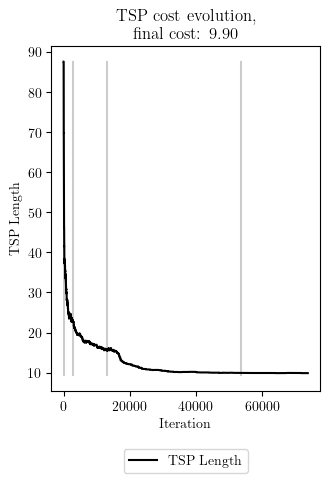

CPU times: total: 6.61 s
Wall time: 7.91 s


In [ ]:
%%timeit -r 20

optimal_random_square_N_100, optimal_random_square_cost_N_100 = simmulated_annealing_tsp(nodes_random_N_100, 
                                                                                  traffic_factor=traffic_factor_with_traffic, 
                                                                                  traffic_start_time=4,
                                                                                  traffic_polygon=traffic_polygon,
                                                                                  start_point_index=0, 
                                                                                  max_iter_per_temperature=1e5,
                                                                                  plot_cost=False, 
                                                                                  plot_cost_out_path='plots/convergence_random_squares_N_100_with_traffic.pdf')

In [ ]:
%%timeit -r 20

random_nodes_in_traffic_polygon = np.array([i for i in range(N) if check_if_in_polygon(nodes_random_N_100[i], traffic_polygon)])
optimal_cost_nearest_neighbor_random_square_N_100_traffic = calculate_route_cost(
    nodes_random_N_100, 
    nearest_neighbor_random_square_N_100, 
    random_nodes_in_traffic_polygon, 
    make_distance_matrix(nodes_random_N_100),
    traffic_factor_with_traffic,
    4.0)
print(f'Optimal cost nearest neighbor random square N 100 with traffic: {optimal_cost_nearest_neighbor_random_square_N_100_traffic}')

Optimal cost nearest neighbor random square N 100 with traffic: 23.714253847992563
